In [42]:
import sys
sys.path.append("..")

from settings import CLEANED_TRANSCRIPTS_CSV

Imports y carga de datos

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

from src.config import CLEANED_TRANSCRIPTS_CSV


In [67]:
df = pd.read_csv(CLEANED_TRANSCRIPTS_CSV)
df.head()

,ID,file_name,transcript,cleaned_transcript
0,/Users/mnariel/Documents/PruebaTecnicaDatec/da...,call_record_01.wav,"Hello, I'm Sarah Miller. I'm calling to inquir...","Hello, I am Sarah Miller. I am calling to inqu..."
1,/Users/mnariel/Documents/PruebaTecnicaDatec/da...,call_record_02.wav,I am extremely dissatisfied with my recent ord...,I am extremely dissatisfied with my recent ord...
2,/Users/mnariel/Documents/PruebaTecnicaDatec/da...,call_record_03.wav,"Hi, this is Maria Rodriguez. I'm having troubl...","Hi, this is Maria Rodriguez. I am having troub..."
3,/Users/mnariel/Documents/PruebaTecnicaDatec/da...,call_record_04.wav,I just wanted to call and say how pleased I am...,I just wanted to call and say how pleased I am...
4,/Users/mnariel/Documents/PruebaTecnicaDatec/da...,call_record_05.wav,"Hello, my name is Jessica Brown. I'd like to p...","Hello, my name is Jessica Brown. I would like ..."


Exploración Inicial

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  20 non-null     object 
 1   file_name           20 non-null     object 
 2   transcript          20 non-null     object 
 3   cleaned_transcript  20 non-null     object 
 4   num_chars           20 non-null     int64  
 5   num_words           20 non-null     int64  
 6   sentiment_score     20 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 1.2+ KB


In [83]:
df.shape

(20, 8)

In [54]:
df.isna().sum()


ID                    0
file_name             0
transcript            0
cleaned_transcript    0
num_chars             0
num_words             0
sentiment_score       0
dtype: int64

In [68]:
df["cleaned_transcript"] = df["cleaned_transcript"].fillna("")

df["num_chars"] = df["cleaned_transcript"].str.len()
df["num_words"] = df["cleaned_transcript"].str.split().str.len()
df["num_sentences"] = df["cleaned_transcript"].str.count(r"[.!?]") + 1

df[["num_chars", "num_words", "num_sentences"]].describe()


,num_chars,num_words,num_sentences
count,20.000000,20.000000,20.000000
mean,332.050000,60.700000,6.950000
std,47.244576,8.844267,0.604805
min,234.000000,42.000000,6.000000
25%,308.000000,54.000000,7.000000
50%,347.500000,62.000000,7.000000
75%,358.000000,66.250000,7.000000
max,420.000000,79.000000,8.000000


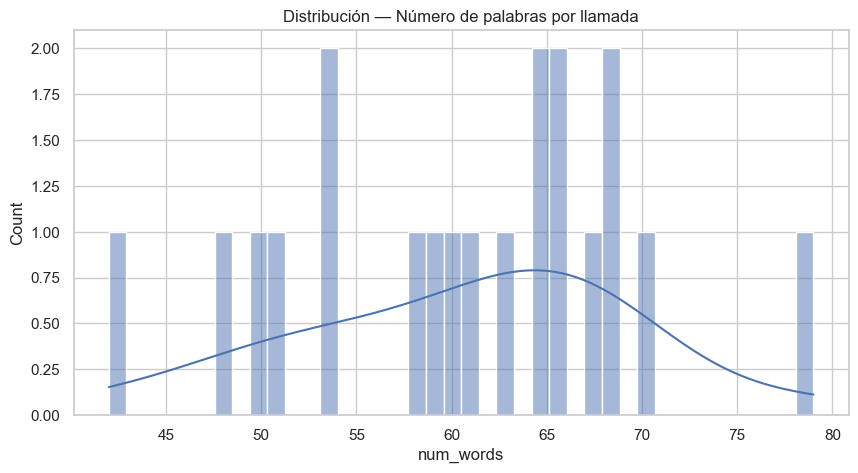

In [69]:
plt.figure(figsize=(10,5))
sns.histplot(df["num_words"], bins=40, kde=True)
plt.title("Distribución — Número de palabras por llamada")
plt.show()

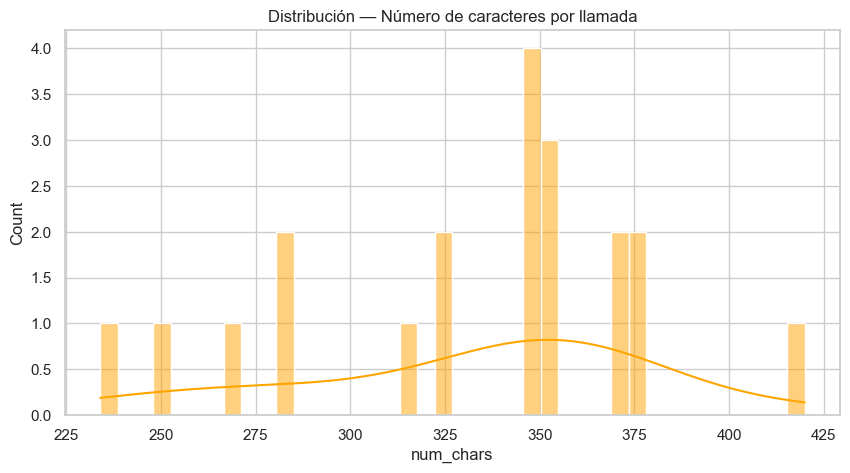

In [70]:
plt.figure(figsize=(10,5))
sns.histplot(df["num_chars"], bins=40, kde=True, color="orange")
plt.title("Distribución — Número de caracteres por llamada")
plt.show()


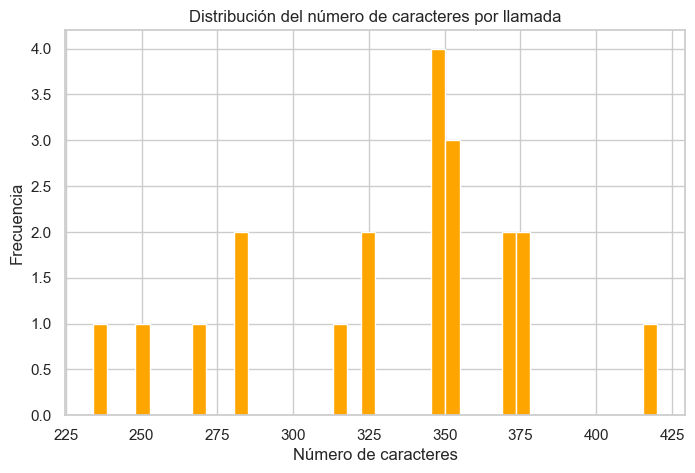

In [58]:
plt.figure(figsize=(8,5))
df["num_chars"].hist(bins=40, color="orange")
plt.title("Distribución del número de caracteres por llamada")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

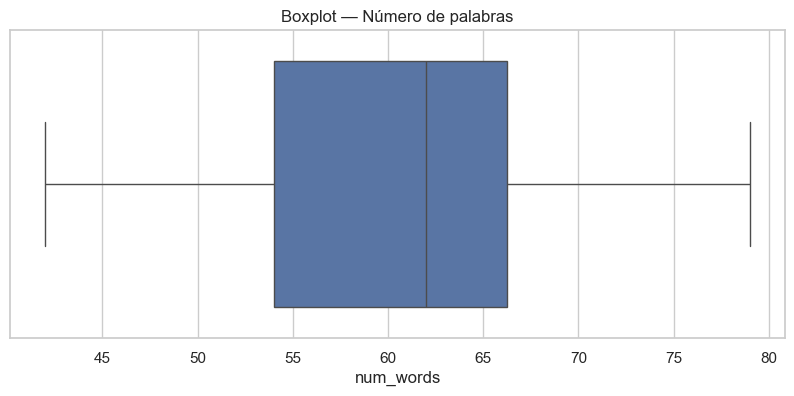

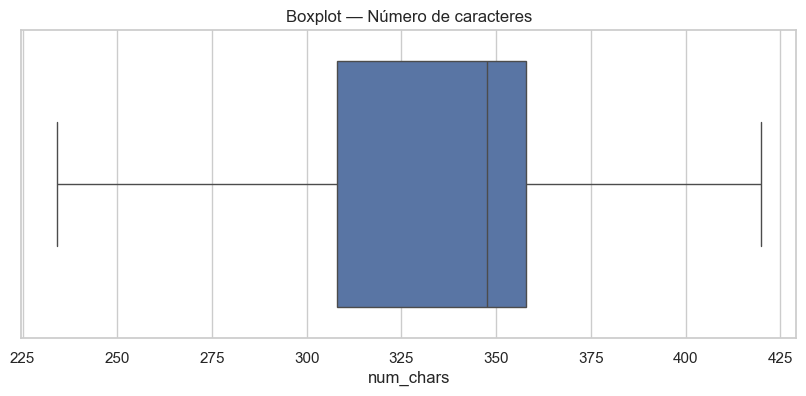

In [71]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["num_words"])
plt.title("Boxplot — Número de palabras")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x=df["num_chars"])
plt.title("Boxplot — Número de caracteres")
plt.show()


Conteo de palabras y análisis léxico

In [72]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

tokens = []
for t in df["cleaned_transcript"]:
    tokens.extend(tokenize(t))

len(tokens), len(set(tokens))

(1233, 519)

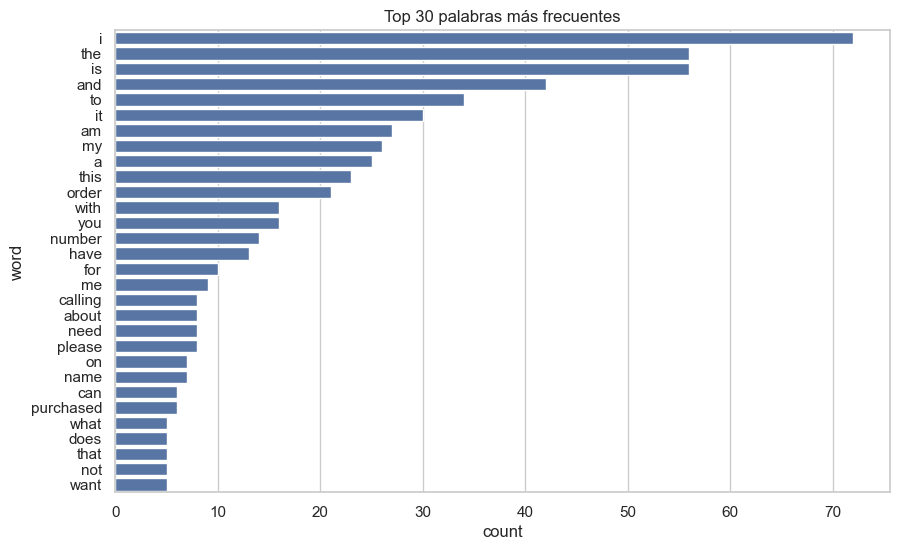

In [74]:
word_counts = Counter(tokens)
common_words = pd.DataFrame(word_counts.most_common(30),
                            columns=["word", "count"])

plt.figure(figsize=(10,6))
sns.barplot(data=common_words, x="count", y="word")
plt.title("Top 30 palabras más frecuentes")
plt.show()

#common_words

In [76]:
from sklearn.feature_extraction.text import CountVectorizer

text_data = df["cleaned_transcript"].tolist()

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), min_df=2)
X2 = bigram_vectorizer.fit_transform(text_data)
bigram_counts = X2.sum(axis=0).A1
bigrams = [(word, bigram_counts[idx]) for word, idx in bigram_vectorizer.vocabulary_.items()]
bigrams = sorted(bigrams, key=lambda x: x[1], reverse=True)[:20]
bigrams

[('order number', 13),
 ('this is', 12),
 ('it is', 11),
 ('number is', 11),
 ('am calling', 7),
 ('with the', 7),
 ('my name', 7),
 ('name is', 7),
 ('my order', 7),
 ('calling to', 6),
 ('and it', 6),
 ('and the', 6),
 ('about the', 5),
 ('can you', 5),
 ('you please', 5),
 ('would like', 5),
 ('like to', 5),
 ('and my', 5),
 ('is the', 4),
 ('does it', 4)]

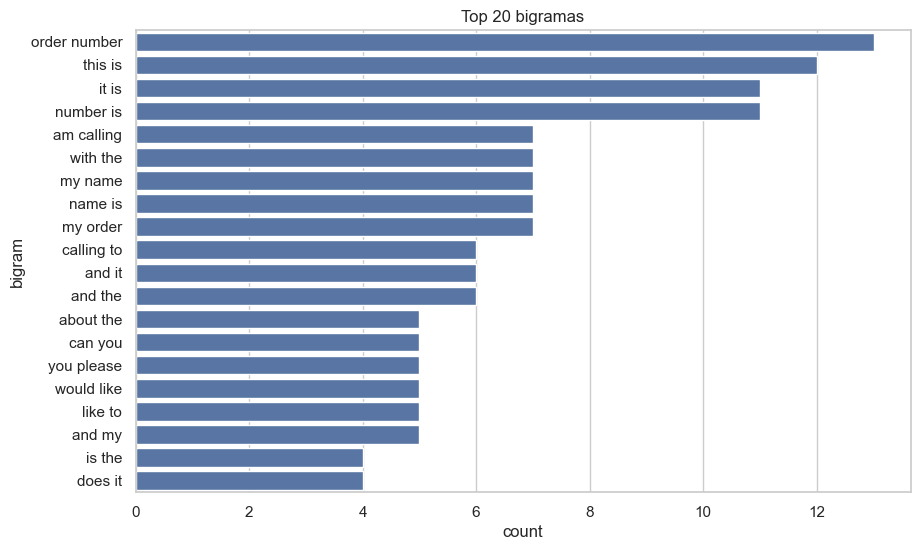

In [77]:
bigram_df = pd.DataFrame(bigrams, columns=["bigram", "count"])

plt.figure(figsize=(10,6))
sns.barplot(data=bigram_df, x="count", y="bigram")
plt.title("Top 20 bigramas")
plt.show()

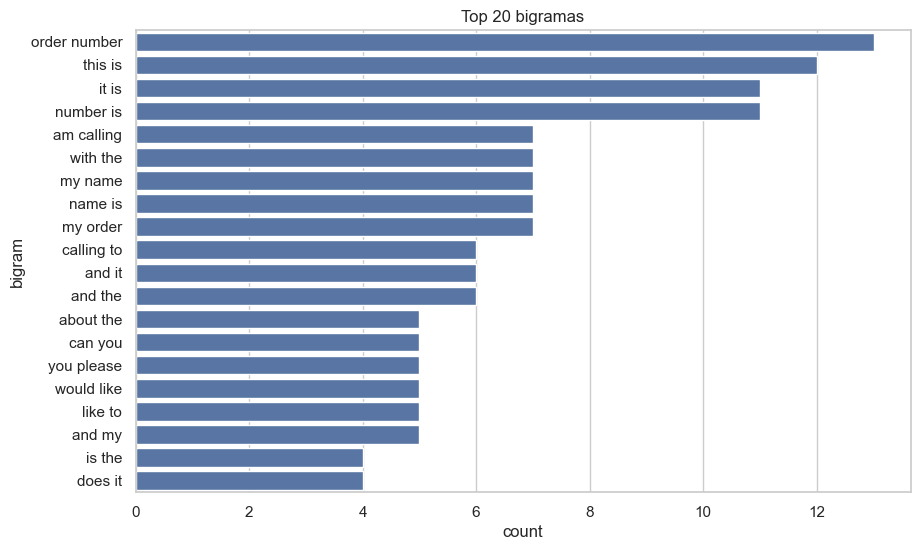

In [78]:
bigram_df = pd.DataFrame(bigrams, columns=["bigram", "count"])

plt.figure(figsize=(10,6))
sns.barplot(data=bigram_df, x="count", y="bigram")
plt.title("Top 20 bigramas")
plt.show()

In [79]:
trigram_vectorizer = CountVectorizer(ngram_range=(3,3), min_df=2)
X3 = trigram_vectorizer.fit_transform(text_data)
trigram_counts = X3.sum(axis=0).A1
trigrams = [(word, trigram_counts[idx]) for word, idx in trigram_vectorizer.vocabulary_.items()]
trigrams = sorted(trigrams, key=lambda x: x[1], reverse=True)[:20]
trigrams

[('order number is', 10),
 ('my name is', 7),
 ('my order number', 6),
 ('am calling to', 5),
 ('would like to', 5),
 ('and my order', 5),
 ('and it is', 4),
 ('what is the', 3),
 ('hi this is', 3),
 ('and the order', 3),
 ('the order number', 3),
 ('hello my name', 3),
 ('like to place', 3),
 ('could you please', 3),
 ('calling to inquire', 2),
 ('to inquire about', 2),
 ('inquire about the', 2),
 ('am calling about', 2),
 ('it is not', 2),
 ('as soon as', 2)]

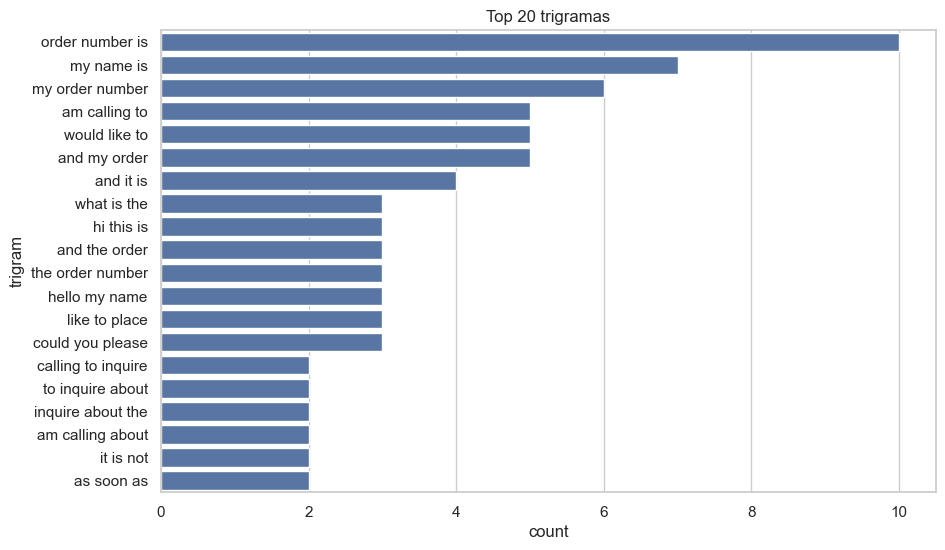

In [80]:
trigram_df = pd.DataFrame(trigrams, columns=["trigram", "count"])

plt.figure(figsize=(10,6))
sns.barplot(data=trigram_df, x="count", y="trigram")
plt.title("Top 20 trigramas")
plt.show()


In [81]:
def classify_length(n):
    if n < 5:
        return "muy_corta"
    elif n < 30:
        return "corta"
    elif n < 80:
        return "media"
    else:
        return "larga"

df["length_category"] = df["num_words"].apply(classify_length)
df["length_category"].value_counts()


length_category
media    20
Name: count, dtype: int64

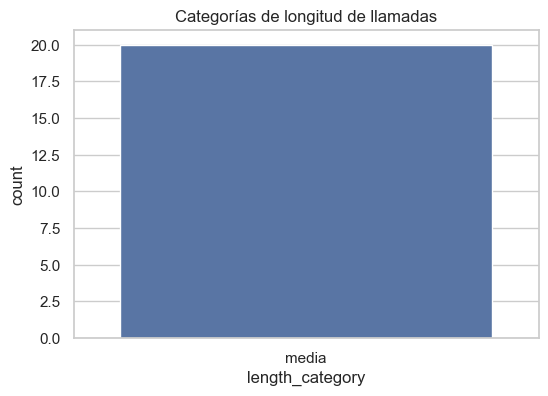

In [82]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="length_category")
plt.title("Categorías de longitud de llamadas")
plt.show()


<Axes: >

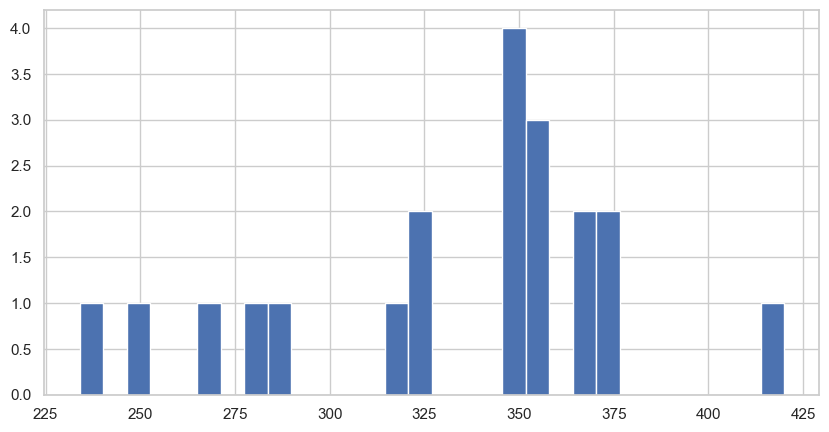

In [85]:
df["num_chars"].hist(bins=30)

In [87]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(df["cleaned_transcript"])
bigrams = vectorizer.get_feature_names_out()

In [88]:
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]


In [89]:
df["num_questions"] = df["cleaned_transcript"].str.count(r"\?")


In [90]:
df["count_I"] = df["cleaned_transcript"].str.count(r"\bI\b")
df["count_you"] = df["cleaned_transcript"].str.count(r"\byou\b")


In [92]:
from textblob import TextBlob
df["sentiment"] = df["cleaned_transcript"].apply(lambda t: TextBlob(t).sentiment.polarity)


<Axes: >

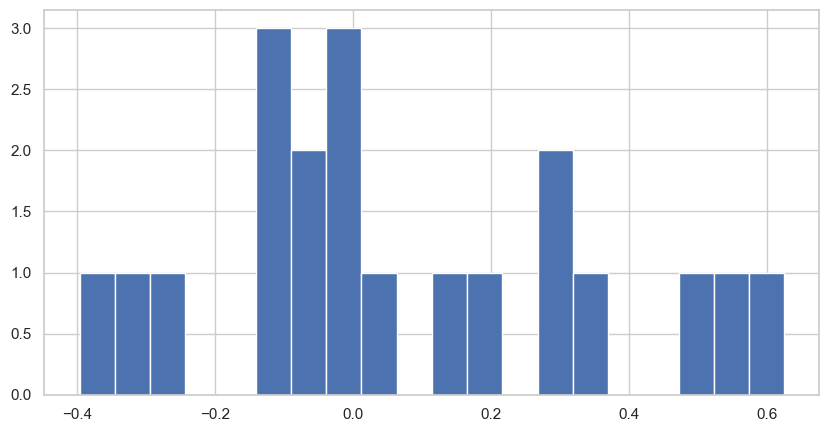

In [93]:
df["sentiment"].hist(bins=20)
